# Транскрибация аудио сигналов

In [1]:
import os
import whisper
from pathlib import PosixPath
import librosa.display
import IPython
import librosa
import torch, torchaudio
from matplotlib import pyplot as plt

## Общая информация о файле

In [2]:
base_dir = PosixPath(os.path.dirname(os.getcwd()))
audio = base_dir / 'result.mp3'
IPython.display.display(IPython.display.Audio(audio))

LANGUAGE = 'ru'

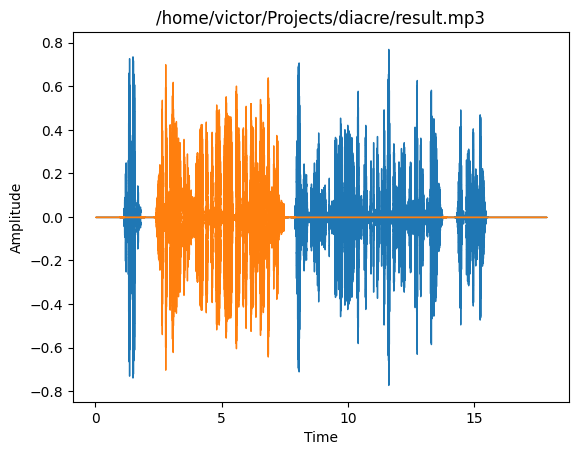

In [3]:
def visual_audio(audio_file: PosixPath) -> None:
    waveform, simple_rate = torchaudio.load(audio)
    plt.title(audio_file)
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    librosa.display.waveshow(waveform[0].numpy(), sr=simple_rate)
    librosa.display.waveshow(waveform[1].numpy(), sr=simple_rate)

visual_audio(audio)

## Спектограмма

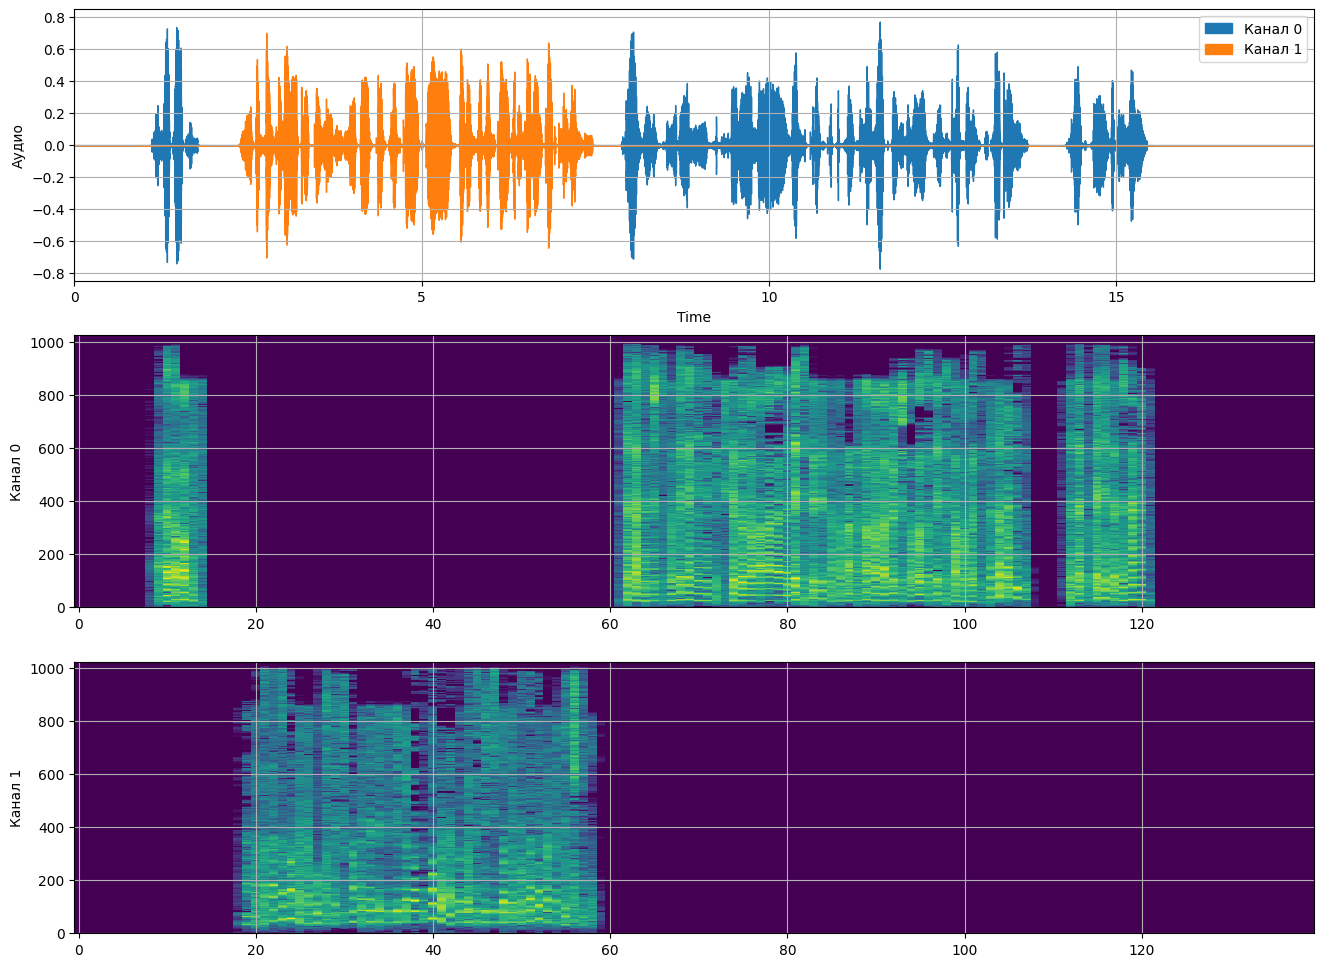

In [4]:
def plot_spectogram(wv, sr, n_fft: int = 2048):
    num_channels, num_frames = wv.shape
    plt.figure(figsize=(16, 12))

    time_axis = torch.arange(0, num_frames) / sr

    ax = plt.subplot(3, 1, 1)
    plt.ylabel('Аудио')
    for channel in range(num_channels):
        librosa.display.waveshow(waveform[channel].numpy(), sr=sr, label=f'Канал {channel}', ax=ax)
    ax.legend()
    ax.grid(True)
    ax.set_xlim([0, time_axis[-1]])
    
    spectrogram = torchaudio.transforms.Spectrogram(n_fft=n_fft)
    spec = spectrogram(wv)

    for channel in range(num_channels):
        # spectogramm
        ax = plt.subplot(3, 1, channel + 2)
        plt.ylabel(f'Канал {channel}')
        ax.imshow(librosa.power_to_db(spec[channel]), origin='lower', aspect='auto', interpolation='nearest')
        ax.grid(True)

waveform, simple_rate = torchaudio.load(audio)
plot_spectogram(waveform, simple_rate)

##  Выполняем транскрибацию звука

In [5]:
# transcribation_model = whisper.load_model(base_dir / 'models' / 'whisper' / 'large-v3-turbo.pt', in_memory=True)
transcribation_model = whisper.load_model(base_dir / 'models' / 'whisper' / 'large-v3.pt', in_memory=True)

/home/victor/Projects/diacre/.venv/lib/python3.9/site-packages/torch/cuda/__init__.py:129: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0
/home/victor/Projects/diacre/.venv/lib/python3.9/site-packages/whisper/__init__.py:150: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a f

In [6]:
from pydantic import BaseModel, ConfigDict


class SegmentWord(BaseModel):
    word: str
    start: float
    end: float

    model_config = ConfigDict(str_strip_whitespace=True)

class Segment(BaseModel):
    channel: int
    start: float
    end: float
    text: str

    words: list[SegmentWord]

    model_config = ConfigDict(str_strip_whitespace=True)



In [7]:

def transcribe(audio_file: PosixPath) -> list[Segment]:
    segments: list[Segment] = []
    SIMPLE_RATE = 16000

    waveform, simple_rate = torchaudio.load(audio_file)
    num_channels, _ = waveform.shape

    channels = [waveform[i, :].unsqueeze(0) for i in range(num_channels)]
    if simple_rate != SIMPLE_RATE:
        resampler = torchaudio.transforms.Resample(simple_rate, SIMPLE_RATE)
        channels = [resampler(channel) for channel in channels]
    channels_numpy = [channel.squeeze(0).numpy() for channel in channels]

    generate_kwargs = {
        'word_timestamps': True,
        'language': LANGUAGE
    }
    for n_channel, cn in enumerate(channels_numpy):
        result = transcribation_model.transcribe(audio=cn, **generate_kwargs)
        segments.extend([
            Segment.model_validate({'channel': n_channel, **segment}) for segment in result['segments']
        ])
    
    return sorted(segments, key=lambda segment: segment.start)

segments = transcribe(audio)

/home/victor/Projects/diacre/.venv/lib/python3.9/site-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")
/home/victor/Projects/diacre/.venv/lib/python3.9/site-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


In [9]:
for segment in segments:
    print(segment)

channel=1 start=2.1200000000000006 end=7.34 text='По станции Новая прокурсив. На ПС-33 Скелет Новая, ВВ-110 Скелет Сухоленка отключен.' words=[SegmentWord(word='По', start=2.1200000000000006, end=2.72), SegmentWord(word='станции', start=2.72, end=3.0), SegmentWord(word='Новая', start=3.0, end=3.22), SegmentWord(word='прокурсив.', start=3.22, end=3.84), SegmentWord(word='На', start=3.92, end=4.1), SegmentWord(word='ПС', start=4.1, end=4.32), SegmentWord(word='-33', start=4.32, end=4.62), SegmentWord(word='Скелет', start=4.62, end=4.94), SegmentWord(word='Новая,', start=4.94, end=5.44), SegmentWord(word='ВВ', start=5.56, end=5.74), SegmentWord(word='-110', start=5.74, end=6.04), SegmentWord(word='Скелет', start=6.04, end=6.3), SegmentWord(word='Сухоленка', start=6.3, end=6.84), SegmentWord(word='отключен.', start=6.84, end=7.34)]
channel=0 start=2.160000000000001 end=2.7 text='Готово.' words=[SegmentWord(word='Готово.', start=2.160000000000001, end=2.7)]
channel=0 start=7.86 end=9.86 tex